In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import constantes as const

In [2]:
# Esto es para que se actualicen los cambios en los archivos importados
%load_ext autoreload
%autoreload 2

In [3]:
from utils.data import DataManager

data_manager = DataManager()
data_manager.preparar_conjuntos()

X_train, y_train, weights_train = data_manager.get_train_data()
X, y = data_manager.get_X_y()
test = data_manager.get_test()
weights = data_manager.get_weights()
X_ = X
X_['Weight']= weights

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [4]:
from imblearn.over_sampling import RandomOverSampler
ros =  RandomOverSampler(sampling_strategy= 'not majority', random_state=42 )
X_res, y_res = ros.fit_resample(X_,y)
weights_res = X_res['Weight']
X_res = X_res.drop(['Weight'], axis=1)

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(X_res, y_res, weights_res, test_size=0.2, random_state=const.RANDOM_STATE)

In [7]:
from utils.preprocess import DataPreprocessor
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve

data_preprocessor = DataPreprocessor()

model = RandomForestClassifier(random_state=const.RANDOM_STATE, class_weight='balanced', n_jobs=12, n_estimators=936, max_depth=40, min_samples_split=5, min_samples_leaf=4, max_features='sqrt')

full_pipeline = Pipeline(steps=[('preprocessor', data_preprocessor),
                                ('classifier', model)])


y_probas_forest = cross_val_predict(full_pipeline, X_train, y_train, cv=3, method="predict_proba")
como
y_scores_forest = y_probas_forest[:, 1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train,y_scores_forest)


In [18]:
from numpy import savetxt

# save to csv file
savetxt('y_probas_forest.csv', y_probas_forest, delimiter=',')
savetxt('fpr_forest.csv', fpr_forest, delimiter=',')
savetxt('tpr_forest.csv', tpr_forest, delimiter=',')
savetxt('thresholds_forest.csv', thresholds_forest, delimiter=',')

In [8]:
from sklearn.model_selection import RandomizedSearchCV

data_preprocessor = DataPreprocessor()
model = RandomForestClassifier(class_weight='balanced', n_jobs=9)

pipeline = Pipeline([
    ('preprocessor', data_preprocessor),
    ('classifier', model)
])

param_dist = {
    'classifier__n_estimators': np.arange(100, 1001, 100),
    'classifier__max_features': ['sqrt'],
    'classifier__max_depth': [None] + list(np.arange(10, 101, 10)),
    'classifier__min_samples_split': np.arange(2, 21, 2),
    'classifier__min_samples_leaf': np.arange(1, 21, 2)
}

random_search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=30, cv=3, verbose=2, random_state=const.RANDOM_STATE, n_jobs=10)

random_search.fit(X, y)

print("Mejores parámetros:", random_search.best_params_)


Fitting 3 folds for each of 30 candidates, totalling 90 fits


c:\users\fcere\miniconda3\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores parámetros: {'classifier__n_estimators': 500, 'classifier__min_samples_split': 6, 'classifier__min_samples_leaf': 7, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 90}


In [9]:
print(y_probas_forest[:10])

[[0.2190046  0.7809954 ]
 [0.44936917 0.55063083]
 [0.08344345 0.91655655]
 [0.79118738 0.20881262]
 [0.09249146 0.90750854]
 [0.98658123 0.01341877]
 [0.70938424 0.29061576]
 [0.98364599 0.01635401]
 [0.99714315 0.00285685]
 [0.09618528 0.90381472]]


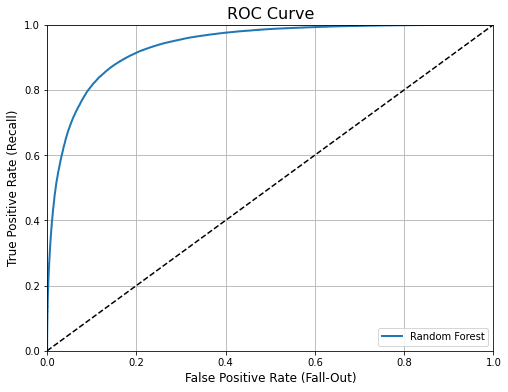

In [10]:
from utils.metrics import MetricsManager

MetricsManager.plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show()

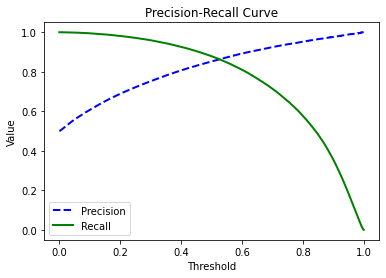

In [11]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_scores_forest = y_probas_forest[:, 1]


MetricsManager.plot_precision_recall_vs_threshold(y_train, y_scores_forest)

In [13]:
from sklearn.metrics import classification_report

full_pipeline.fit(X_train, y_train, classifier__sample_weight=weights_train)
y_probas = full_pipeline.predict_proba(X_test)
y_scores = y_probas[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)


best_threshold = MetricsManager.get_best_threshold(precision, recall, thresholds)

y_pred_optimal = (y_scores >= best_threshold).astype(int)

#print(classification_report(y_test, y_pred_optimal))


In [14]:
print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84     33153
           1       0.82      0.89      0.85     32581

    accuracy                           0.85     65734
   macro avg       0.85      0.85      0.85     65734
weighted avg       0.85      0.85      0.85     65734



In [15]:
y_test_proba = full_pipeline.predict_proba(test)
y_test_scores = y_test_proba[:, 1]
y_test_pred = (y_test_scores >= best_threshold).astype(int)

submission_df = pd.DataFrame({
    "EventId": test["EventId"],
    "Class": y_test_pred,
    "Probability": y_test_scores
})

submission_df = submission_df.sort_values(by='Probability', ascending=False)

submission_df['RankOrder'] = range(1, len(submission_df) + 1)
submission_df['Class'] = submission_df['Class'].map({1: 's', 0: 'b'})

submission_df = submission_df[['EventId', 'Class', 'RankOrder']]

submission_df.to_csv("submission.csv", index=False)

In [21]:
!kaggle competitions submit -c higgs-boson -f submission.csv -m "on ros 01 submission"

Successfully submitted to Higgs Boson Machine Learning Challenge


  0%|          | 0.00/8.81M [00:00<?, ?B/s]
  0%|          | 8.00k/8.81M [00:00<02:00, 76.8kB/s]
  3%|2         | 256k/8.81M [00:00<01:22, 108kB/s]  
  7%|6         | 608k/8.81M [00:00<00:56, 153kB/s]
 10%|9         | 888k/8.81M [00:00<00:39, 211kB/s]
 12%|#1        | 1.03M/8.81M [00:00<00:28, 284kB/s]
 13%|#3        | 1.19M/8.81M [00:00<00:21, 369kB/s]
 20%|#9        | 1.76M/8.81M [00:00<00:14, 511kB/s]
 24%|##3       | 2.10M/8.81M [00:00<00:10, 688kB/s]
 29%|##9       | 2.58M/8.81M [00:01<00:07, 918kB/s]
 33%|###2      | 2.89M/8.81M [00:01<00:05, 1.06MB/s]
 36%|###5      | 3.16M/8.81M [00:01<00:04, 1.29MB/s]
 39%|###8      | 3.42M/8.81M [00:01<00:04, 1.36MB/s]
 41%|####1     | 3.66M/8.81M [00:01<00:03, 1.56MB/s]
 44%|####4     | 3.88M/8.81M [00:01<00:02, 1.73MB/s]
 47%|####7     | 4.16M/8.81M [00:01<00:02, 1.79MB/s]
 52%|#####1    | 4.57M/8.81M [00:02<00:02, 2.07MB/s]
 57%|#####6    | 5.02M/8.81M [00:02<00:01, 2.46MB/s]
 61%|######    | 5.35M/8.81M [00:02<00:01, 2.56MB/s]
 70%|#####

In [22]:
from comet_ml import Experiment
def ams_scorer(y_true, y_pred, weights):
    """ Custom scorer function for calculating AMS.

    Args:
        y_true (array): True labels.
        y_pred (array): Predicted labels.
        weights (array): Event weights.

    Returns:
        float: The calculated AMS score.
    """
    true_signal = (y_true == 1)
    pred_signal = (y_pred == 1)

    signal = np.sum(weights[true_signal & pred_signal])
    print('signal = {0}'.format(signal))
    background = np.sum(weights[~true_signal & pred_signal])
    print('background = {0}'.format(background))

    return AMS(signal, background)

def exp_eval_classifier(model, X_test, y_test, sample_weight, model_name, api_key):
    experiment = Experiment(
        api_key=api_key,
        project_name="proyecto-1-taa",
        workspace="xqft"
    )
    experiment.set_name("Evaluate " + model_name)
    experiment.add_tags(["Evaluation", model_name])

    experiment.log_metric("AMS", ams_scorer(y_test, model.predict(X_test), sample_weight))
    experiment.end()
    
def exp_tune_classifier(model_name, search, api_key):
    for i in range(len(search.cv_results_['params'])):
        experiment = Experiment(
            api_key=api_key,
            project_name="proyecto-1-taa",
            workspace="xqft"
        )
        experiment.add_tags(["Hyperparameter tuning", model_name])
        experiment.set_name("Tune " + model_name + f" (iter {i})")

        for k, v in search.cv_results_.items():
            if k == "params":
                experiment.log_parameters(v[i])
            else:
                experiment.log_metric(k, v[i])
        experiment.end()

[autoreload of pygments.token failed: Traceback (most recent call last):
  File "c:\users\fcere\miniconda3\lib\site-packages\IPython\extensions\autoreload.py", line 245, in check
    superreload(m, reload, self.old_objects)
  File "c:\users\fcere\miniconda3\lib\site-packages\IPython\extensions\autoreload.py", line 410, in superreload
    update_generic(old_obj, new_obj)
  File "c:\users\fcere\miniconda3\lib\site-packages\IPython\extensions\autoreload.py", line 347, in update_generic
    update(a, b)
  File "c:\users\fcere\miniconda3\lib\site-packages\IPython\extensions\autoreload.py", line 317, in update_class
    update_instances(old, new)
  File "c:\users\fcere\miniconda3\lib\site-packages\IPython\extensions\autoreload.py", line 280, in update_instances
    ref.__class__ = new
TypeError: __class__ assignment: '_TokenType' object layout differs from '_TokenType'
]
[autoreload of pygments.lexer failed: Traceback (most recent call last):
  File "c:\users\fcere\miniconda3\lib\site-packag

In [ ]:
#from utils.comet_experiments import exp_tune_classifier
exp_tune_classifier("RandomForestROS", random_search, "tZzHrgZeB2lMeZSSnDvSFUAIV")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/xqft/proyecto-1-taa/5050200c5cbc486fb79a8b2159c7082c

COMET INFO: Couldn't find a Git repository in 'C:\\Users\\fcere\\downloads\\Laboratorio1_TAA-main-15-4\\Laboratorio1_TAA-main' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET WARNING: You are trying to log string value as a metric. This is not recommended.
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_

COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Tune RandomForestROS (iter 2)
COMET INFO:     url                   : https://www.comet.com/xqft/proyecto-1-taa/d0c7477b03794560b64b07ea62ec9bf6
COMET INFO:   Metrics:
COMET INFO:     mean_fit_time                       : 1039.1309611797333
COMET INFO:     mean_score_time                     : 40.29804261525472
COMET INFO:     mean_test_score                     : 1.0
COMET INFO:     param_classifier__max_depth         : 60
COMET INFO:     param_classifier__max_features      : sqrt
COMET INFO:     param_classifier__min_samples_leaf  : 13
COMET INFO:     param_classifier__min_samples_split : 20
COMET INFO:     param_classifier__n_estimators      : 300
COMET INFO:     rank_test_score                     : 1
COMET INFO:     split0_test_score          

COMET INFO:     param_classifier__max_features      : sqrt
COMET INFO:     param_classifier__min_samples_leaf  : 3
COMET INFO:     param_classifier__min_samples_split : 2
COMET INFO:     param_classifier__n_estimators      : 600
COMET INFO:     rank_test_score                     : 1
COMET INFO:     split0_test_score                   : 1.0
COMET INFO:     split1_test_score                   : 1.0
COMET INFO:     split2_test_score                   : 1.0
COMET INFO:     std_fit_time                        : 21.68900723301525
COMET INFO:     std_score_time                      : 5.445682935289203
COMET INFO:     std_test_score                      : 0.0
COMET INFO:   Others:
COMET INFO:     Name : Tune RandomForestROS (iter 4)
COMET INFO:   Parameters:
COMET INFO:     classifier__max_depth         : 20
COMET INFO:     classifier__max_features      : sqrt
COMET INFO:     classifier__min_samples_leaf  : 3
COMET INFO:     classifier__min_samples_split : 2
COMET INFO:     classifier__n_esti

COMET INFO:   Others:
COMET INFO:     Name : Tune RandomForestROS (iter 6)
COMET INFO:   Parameters:
COMET INFO:     classifier__max_depth         : 50
COMET INFO:     classifier__max_features      : sqrt
COMET INFO:     classifier__min_samples_leaf  : 5
COMET INFO:     classifier__min_samples_split : 12
COMET INFO:     classifier__n_estimators      : 200
COMET INFO:   Uploads:
COMET INFO:     conda-environment-definition : 1
COMET INFO:     conda-info                   : 1
COMET INFO:     conda-specification          : 1
COMET INFO:     environment details          : 1
COMET INFO:     filename                     : 1
COMET INFO:     installed packages           : 1
COMET INFO:     notebook                     : 1
COMET INFO:     source_code                  : 1
COMET INFO: 
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn.
COMET INFO: Please wait for metadata to finish uploading (timeout is 3600 seconds)
COMET INFO: Uploading 4

COMET INFO:     conda-specification          : 1
COMET INFO:     environment details          : 1
COMET INFO:     filename                     : 1
COMET INFO:     installed packages           : 1
COMET INFO:     notebook                     : 1
COMET INFO:     source_code                  : 1
COMET INFO: 
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn.
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in 'C:\\Users\\fcere\\downloads\\Laboratorio1_TAA-main-15-4\\Laboratorio1_TAA-main' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/xqft/proyecto-1-taa

...

COMET INFO:     classifier__max_depth         : 80
COMET INFO:     classifier__max_features      : sqrt
COMET INFO:     classifier__min_samples_leaf  : 3
COMET INFO:     classifier__min_samples_split : 12
COMET INFO:     classifier__n_estimators      : 900
COMET INFO:   Uploads:
COMET INFO:     conda-environment-definition : 1
COMET INFO:     conda-info                   : 1
COMET INFO:     conda-specification          : 1
COMET INFO:     environment details          : 1
COMET INFO:     filename                     : 1
COMET INFO:     installed packages           : 1
COMET INFO:     notebook                     : 1
COMET INFO:     source_code                  : 1
COMET INFO: 
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn.
COMET INFO: Uploading 1 metrics, params and output messages
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn.
COMET WARNING: As you are running in a 

COMET INFO:     notebook                     : 1
COMET INFO:     source_code                  : 1
COMET INFO: 
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn.
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in 'C:\\Users\\fcere\\downloads\\Laboratorio1_TAA-main-15-4\\Laboratorio1_TAA-main' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/xqft/proyecto-1-taa/35d3870b1bd94dd5a1ae27910fc9c7ff

COMET WARNING: The given value of the metric param_classifier__max_depth was None; ignoring
COMET INFO: ---------------------------------------------------------

COMET INFO: Experiment is live on comet.com https://www.comet.com/xqft/proyecto-1-taa/f69b5b6f88b34c65b6034dab0af8c68d

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Tune RandomForestROS (iter 22)
COMET INFO:     url                   : https://www.comet.com/xqft/proyecto-1-taa/f69b5b6f88b34c65b6034dab0af8c68d
COMET INFO:   Metrics:
COMET INFO:     mean_fit_time                       : 2187.2860005696616
COMET INFO:     mean_score_time                     : 51.320539474487305
COMET INFO:     mean_test_score                     : 1.0
COMET INFO:     param_classifier__max_depth         : 60
COMET INFO:     param_classifier__max_features      : sqrt
COMET INFO:     param_classifier__min_samples_lea

COMET INFO:   Metrics:
COMET INFO:     mean_fit_time                       : 3658.8239843845367
COMET INFO:     mean_score_time                     : 82.84762056668599
COMET INFO:     mean_test_score                     : 1.0
COMET INFO:     param_classifier__max_depth         : 50
COMET INFO:     param_classifier__max_features      : sqrt
COMET INFO:     param_classifier__min_samples_leaf  : 3
COMET INFO:     param_classifier__min_samples_split : 4
COMET INFO:     param_classifier__n_estimators      : 1000
COMET INFO:     rank_test_score                     : 1
COMET INFO:     split0_test_score                   : 1.0
COMET INFO:     split1_test_score                   : 1.0
COMET INFO:     split2_test_score                   : 1.0
COMET INFO:     std_fit_time                        : 18.419518675013055
COMET INFO:     std_score_time                      : 6.547799498573966
COMET INFO:     std_test_score                      : 0.0
COMET INFO:   Others:
COMET INFO:     Name : Tune Rand

COMET INFO:     split2_test_score                   : 1.0
COMET INFO:     std_fit_time                        : 38.40553920533183
COMET INFO:     std_score_time                      : 1.610574000184121
COMET INFO:     std_test_score                      : 0.0
COMET INFO:   Others:
COMET INFO:     Name : Tune RandomForestROS (iter 26)
COMET INFO:   Parameters:
COMET INFO:     classifier__max_depth         : 50
COMET INFO:     classifier__max_features      : sqrt
COMET INFO:     classifier__min_samples_leaf  : 3
COMET INFO:     classifier__min_samples_split : 12
COMET INFO:     classifier__n_estimators      : 600
COMET INFO:   Uploads:
COMET INFO:     conda-environment-definition : 1
COMET INFO:     conda-info                   : 1
COMET INFO:     conda-specification          : 1
COMET INFO:     environment details          : 1
COMET INFO:     filename                     : 1
COMET INFO:     installed packages           : 1
COMET INFO:     notebook                     : 1
COMET INFO:    

In [17]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=3, shuffle=True, random_state=const.RANDOM_STATE)

y_probas_forest = np.array([])

for train_index, test_index in kf.split(X_train):

    X_train_fold, X_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
    y_train_fold, y_test_fold = y_train[train_index], y_train[test_index]
    weights_train_fold = weights_train.iloc[train_index]
    
    full_pipeline.fit(X_train_fold, y_train_fold, classifier__sample_weight=weights_train_fold)

    y_probas_fold = full_pipeline.predict_proba(X_test_fold)[:, 1]
    
    y_probas_forest = np.concatenate((y_probas_forest, y_probas_fold))

fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train, y_probas_forest)


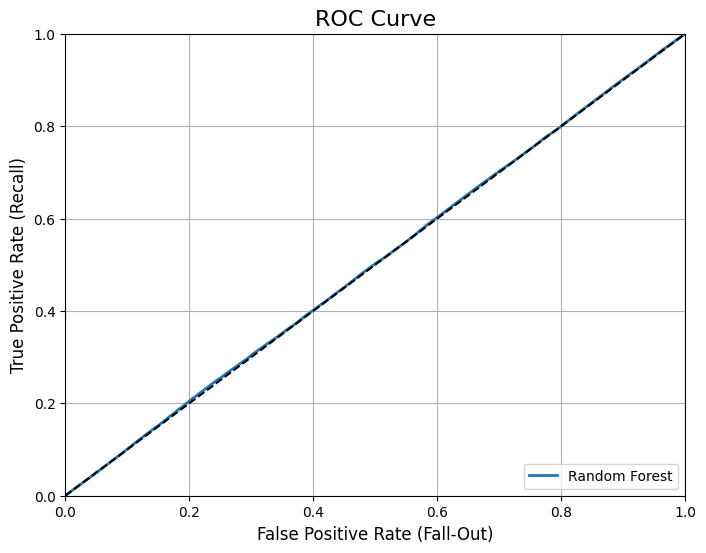

In [18]:
MetricsManager.plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show()

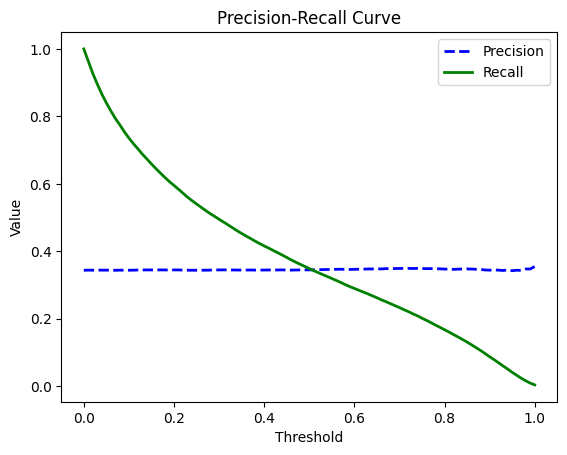

In [22]:
y_scores_forest = y_probas_forest

MetricsManager.plot_precision_recall_vs_threshold(y_train, y_scores_forest)

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.datasets import load_iris
import numpy as np

# Suponiendo que tienes datos cargados en X_train y y_train
X_train, y_train = load_iris(return_X_y=True)

# Definir un modelo y un preprocesador (este es solo un ejemplo)
model = RandomForestClassifier()
preprocess = None  # Reemplaza esto con tu preprocesador real

# Configurar el pipeline
full_pipeline = Pipeline(steps=[('preprocessor', preprocess),
                                ('classifier', model)])

def objective(trial):
    # Definir los espacios de búsqueda de los hiperparámetros
    param = {
        'classifier__n_estimators': trial.suggest_int('classifier__n_estimators', 50, 200),
        'classifier__max_depth': trial.suggest_int('classifier__max_depth', 3, 15),
        # Añade aquí más hiperparámetros para optimizar
    }

    # Seteamos los hiperparámetros en el pipeline
    full_pipeline.set_params(**param)

    # Realizamos validación cruzada
    scores = cross_val_score(full_pipeline, X_train, y_train, 
                             scoring='roc_auc', cv=KFold(n_splits=3, shuffle=True, random_state=3565436))

    # Optuna minimiza, por lo que devolvemos el negativo del roc_auc promedio
    return -np.mean(scores)

# Creación del estudio de Optuna que optimizará la función objetivo
study = optuna.create_study(direction='minimize')

study.optimize(objective, n_trials=100, n_jobs=12)

print('Number of finished trials:', len(study.trials))
print('Best trial:')
trial = study.best_trial

print('  Value: {}'.format(-trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print(f'    {key}: {value}')


In [16]:
from sklearn.metrics import f1_score, make_scorer

# Definir una función de puntuación F1 para usar en la validación cruzada
def f1_scorer(y_true, y_pred):
    # Calcula el F1-score
    score = f1_score(y_true, y_pred, average='macro')  # 'macro' para multiclase sin ponderar
    return score

# Crear un scorer utilizando make_scorer de scikit-learn
custom_f1_scorer = make_scorer(f1_scorer)


In [30]:
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.datasets import load_iris
import numpy as np


def objective(trial):
    # Definir los espacios de búsqueda de los hiperparámetros
    param = {
        'classifier__n_estimators': trial.suggest_int('classifier__n_estimators', 900, 1300),
        'classifier__max_depth': trial.suggest_int('classifier__max_depth', 40,60),
        'classifier__min_samples_split': trial.suggest_int('classifier__min_samples_split', 3,6),
        'classifier__min_samples_leaf': trial.suggest_int('classifier__min_samples_leaf', 2,5),

        # Puedes añadir más parámetros aquí
    }

    # Setear los hiperparámetros en el pipeline
    full_pipeline.set_params(**param)

    # Realizar validación cruzada utilizando el scorer personalizado de F1
    scores = cross_val_score(full_pipeline, X_train, y_train, scoring=custom_f1_scorer, cv=KFold(n_splits=3, shuffle=True, random_state=3565436))

    # Optuna minimiza, por lo que devolvemos el negativo del F1-score promedio
    return -np.mean(scores)

# Crear y ejecutar el estudio de Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, n_jobs=10)

# Imprimir los resultados
print('Number of finished trials:', len(study.trials))
print('Best trial:')
trial = study.best_trial
print('  Value: {}'.format(-trial.value))
for key, value in trial.params.items():
    print(f'    {key}: {value}')

# 'classifier__n_estimators': 1000, 'classifier__min_samples_split': 4, 'classifier__min_samples_leaf': 3, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 50


[I 2024-04-14 12:04:40,236] A new study created in memory with name: no-name-0d0a311f-896b-4cac-8dd7-8f03784a1c33
[I 2024-04-14 12:34:31,654] Trial 2 finished with value: -0.8186433801873122 and parameters: {'classifier__n_estimators': 979, 'classifier__max_depth': 41, 'classifier__min_samples_split': 6, 'classifier__min_samples_leaf': 3}. Best is trial 2 with value: -0.8186433801873122.
[I 2024-04-14 12:34:49,391] Trial 1 finished with value: -0.8186433801873122 and parameters: {'classifier__n_estimators': 1131, 'classifier__max_depth': 47, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 3}. Best is trial 2 with value: -0.8186433801873122.
[I 2024-04-14 12:34:54,429] Trial 7 finished with value: -0.8186248825144672 and parameters: {'classifier__n_estimators': 1265, 'classifier__max_depth': 60, 'classifier__min_samples_split': 6, 'classifier__min_samples_leaf': 3}. Best is trial 2 with value: -0.8186433801873122.
[I 2024-04-14 12:35:03,058] Trial 6 finished with val

Number of finished trials: 100
Best trial:
  Value: 0.818765740686275
    classifier__n_estimators: 936
    classifier__max_depth: 40
    classifier__min_samples_split: 5
    classifier__min_samples_leaf: 4
